# EDA IMERG 2025-2026

Notebook này phân tích riêng file IMERG đã crop cho giai đoạn 2025-2026. Nó không tải dữ liệu và không chuẩn hóa rainfall.

Các phần gồm: integrity, phân bố cường độ mưa, bản đồ không gian, seasonality, kiểm tra coverage và cửa sổ nowcasting 6+4. Đơn vị kỳ vọng: `mm/30 min`.

In [ ]:
import sys
import subprocess
from pathlib import Path

if "google.colab" in sys.modules:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "xarray", "netCDF4", "pandas", "numpy", "matplotlib", "seaborn",
    ])

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

try:
    from google.colab import drive

    drive.mount("/content/drive")
    IN_COLAB = True
    PROJECT_DIR = Path("/content/drive/MyDrive/Rainfall_Nowcasting/IMERG")
except ImportError:
    IN_COLAB = False
    PROJECT_DIR = Path.cwd().resolve()

NETCDF_PATH = PROJECT_DIR / "data" / "imerg_vietnam" / "imerg_vietnam_2025_2026.nc"
FIG_DIR = PROJECT_DIR / "figures_eda_2025_2026"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"Running in Colab: {IN_COLAB}")
print(f"Expected NetCDF: {NETCDF_PATH}")

Mounted at /content/drive
Running in Colab: True
Expected NetCDF: /content/drive/MyDrive/Rainfall_Nowcasting/IMERG/data/imerg_vietnam/imerg_vietnam_2025_2026.nc


In [ ]:
if not NETCDF_PATH.exists():
    candidates = sorted(PROJECT_DIR.rglob("imerg_vietnam_2025_2026.nc"))
    print("Không tìm thấy file mặc định. Các file phù hợp:")
    for candidate in candidates:
        print(candidate)
    raise FileNotFoundError(f"Hãy sửa NETCDF_PATH. Không tìm thấy: {NETCDF_PATH}")

with xr.open_dataset(NETCDF_PATH) as dataset:
    variable_names = list(dataset.data_vars)
    rainfall_name = "rainfall" if "rainfall" in variable_names else variable_names[0]
    rain = dataset[rainfall_name].load()

if "time" not in rain.dims:
    raise ValueError(f"Biến {rainfall_name!r} không có dimension time: {rain.dims}")

rain = rain.sortby("time")
actual_time = pd.DatetimeIndex(pd.to_datetime(rain.time.values))
print(f"Loaded variable: {rainfall_name}")
print(f"File: {NETCDF_PATH}")
print(f"Date range: {actual_time.min()} -> {actual_time.max()}")
print(f"Shape: {rain.shape}")
print(f"Dimensions: {rain.dims}")
print(f"Units: {rain.attrs.get('units', 'unknown')}")

Loaded variable: rainfall
File: /content/drive/MyDrive/Rainfall_Nowcasting/IMERG/data/imerg_vietnam/imerg_vietnam_2025_2026.nc
Date range: 2025-01-01 00:00:00 -> 2025-09-30 23:30:00
Shape: (13104, 165, 80)
Dimensions: ('time', 'lat', 'lon')
Units: mm/30 min


## 1. Data integrity

Kiểm tra timestep thiếu/trùng, khoảng thời gian, shape, tọa độ, NaN và giá trị bất thường.

In [ ]:
expected_time = pd.date_range(
    "2025-01-01T00:00:00",
    "2026-12-31T23:30:00",
    freq="30min",
)
missing_time = expected_time.difference(actual_time)
extra_time = actual_time.difference(expected_time)
duplicate_time = actual_time[actual_time.duplicated()]
intervals = actual_time.to_series().diff().dropna()

values = rain.values
finite_values = values[np.isfinite(values)]
invalid_count = int(np.sum((finite_values < 0) | (finite_values > 500)))
integrity = pd.Series({
    "expected_timesteps": len(expected_time),
    "actual_timesteps": len(actual_time),
    "missing_timesteps": len(missing_time),
    "extra_timesteps": len(extra_time),
    "duplicate_timesteps": len(duplicate_time),
    "minimum_interval": intervals.min() if len(intervals) else pd.NaT,
    "maximum_interval": intervals.max() if len(intervals) else pd.NaT,
    "shape_time_lat_lon": tuple(rain.shape),
    "nan_fraction": float(np.isnan(values).mean()),
    "negative_or_implausible_values": invalid_count,
    "latitude_range": (float(rain.lat.min()), float(rain.lat.max())),
    "longitude_range": (float(rain.lon.min()), float(rain.lon.max())),
})
print(integrity)
if len(missing_time):
    print("First missing timestamps:", missing_time[:20].tolist())
if len(duplicate_time):
    print("Duplicate timestamps:", duplicate_time[:20].tolist())
print("Interval counts:")
print(intervals.value_counts().sort_index())

expected_timesteps                                                   35040
actual_timesteps                                                     13104
missing_timesteps                                                    21936
extra_timesteps                                                          0
duplicate_timesteps                                                      0
minimum_interval                                           0 days 00:30:00
maximum_interval                                           0 days 00:30:00
shape_time_lat_lon                                        (13104, 165, 80)
nan_fraction                                                           0.0
negative_or_implausible_values                                           0
latitude_range                      (8.050000190734863, 24.44999885559082)
longitude_range                   (102.04999542236328, 109.94999694824219)
dtype: object
First missing timestamps: [Timestamp('2025-10-01 00:00:00'), Timestamp('2025-10-01 00:

## 2. Phân bố lượng mưa

Thống kê theo các nhóm: không mưa `<0.1`, nhẹ `0.1-2.5`, vừa `2.5-10`, lớn `10-50`, cực đoan `>=50` mm/30 min. Dữ liệu chỉ được lấy mẫu để vẽ histogram, không biến đổi giá trị.

count            1.729728e+08
min              0.000000e+00
max              4.920000e+01
mean             1.271330e-01
median_sample    0.000000e+00
p90_sample       0.000000e+00
p95_sample       0.000000e+00
p99_sample       3.750000e-01
p99_9_sample     1.330000e+00
nan_fraction     0.000000e+00
dtype: float64
             pixels    percent
no rain   151738447  87.723877
light      19288039  11.150909
moderate    1851584   1.070448
heavy         94730   0.054766
extreme           0   0.000000


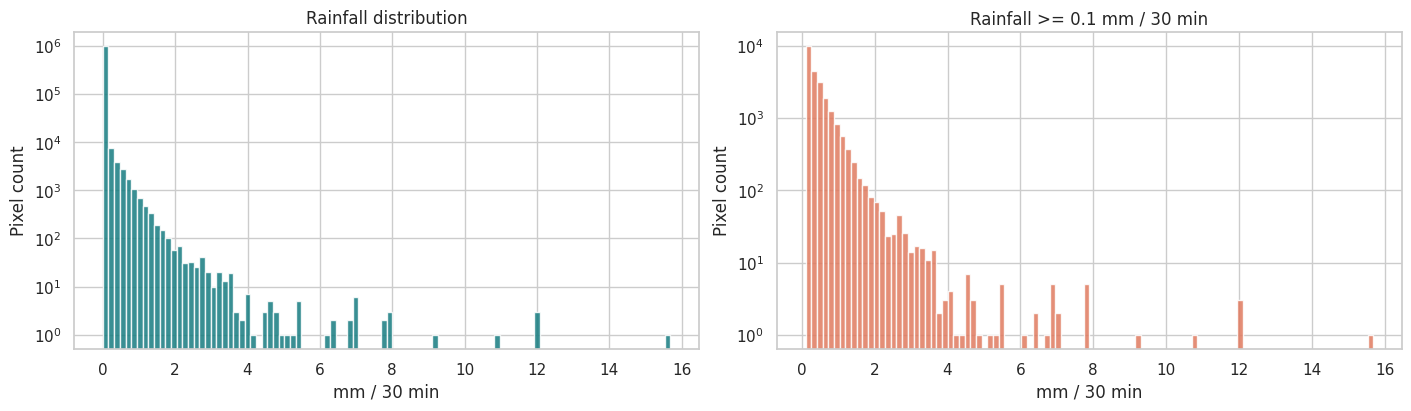

In [ ]:
CHUNK_TIMESTEPS = 256
MAX_SAMPLE_VALUES = 1_000_000
value_count = 0
value_sum = 0.0
value_min = np.inf
value_max = -np.inf
nan_count = 0
class_counts = np.zeros(5, dtype=np.int64)
sample_parts = []

for start in range(0, rain.sizes["time"], CHUNK_TIMESTEPS):
    chunk = rain.isel(time=slice(start, start + CHUNK_TIMESTEPS)).values
    nan_count += int(np.isnan(chunk).sum())
    finite = chunk[np.isfinite(chunk)]
    finite = finite[finite >= 0]
    if finite.size == 0:
        continue
    value_count += finite.size
    value_sum += float(finite.sum(dtype=np.float64))
    value_min = min(value_min, float(finite.min()))
    value_max = max(value_max, float(finite.max()))
    class_counts += np.array([
        np.count_nonzero(finite < 0.1),
        np.count_nonzero((finite >= 0.1) & (finite < 2.5)),
        np.count_nonzero((finite >= 2.5) & (finite < 10)),
        np.count_nonzero((finite >= 10) & (finite < 50)),
        np.count_nonzero(finite >= 50),
    ])
    remaining = MAX_SAMPLE_VALUES - sum(part.size for part in sample_parts)
    if remaining > 0:
        step = max(1, finite.size // remaining)
        sample_parts.append(finite[::step][:remaining])

if value_count == 0:
    raise ValueError("Không có pixel rainfall hợp lệ để phân tích.")
sample_values = np.concatenate(sample_parts)[:MAX_SAMPLE_VALUES]
percentiles = np.percentile(sample_values, [50, 90, 95, 99, 99.9])
print(pd.Series({
    "count": value_count,
    "min": value_min,
    "max": value_max,
    "mean": value_sum / value_count,
    "median_sample": percentiles[0],
    "p90_sample": percentiles[1],
    "p95_sample": percentiles[2],
    "p99_sample": percentiles[3],
    "p99_9_sample": percentiles[4],
    "nan_fraction": nan_count / rain.size,
}))

labels = ["no rain", "light", "moderate", "heavy", "extreme"]
class_table = pd.DataFrame({"pixels": class_counts, "percent": class_counts / value_count * 100}, index=labels)
print(class_table)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)
axes[0].hist(sample_values, bins=100, color="#167c80", alpha=0.85)
axes[0].set_title("Rainfall distribution")
axes[0].set_xlabel("mm / 30 min")
axes[0].set_ylabel("Pixel count")
axes[0].set_yscale("log")
wet_values = sample_values[sample_values >= 0.1]
axes[1].hist(wet_values, bins=100, color="#e07a5f", alpha=0.85)
axes[1].set_title("Rainfall >= 0.1 mm / 30 min")
axes[1].set_xlabel("mm / 30 min")
axes[1].set_ylabel("Pixel count")
axes[1].set_yscale("log")
plt.savefig(FIG_DIR / "rainfall_distribution_2025_2026.png", dpi=160)
plt.show()

## 3. Không gian và thời gian

Tạo mean/max map, các frame mẫu, chuỗi trung bình không gian và tổng mưa theo tháng.

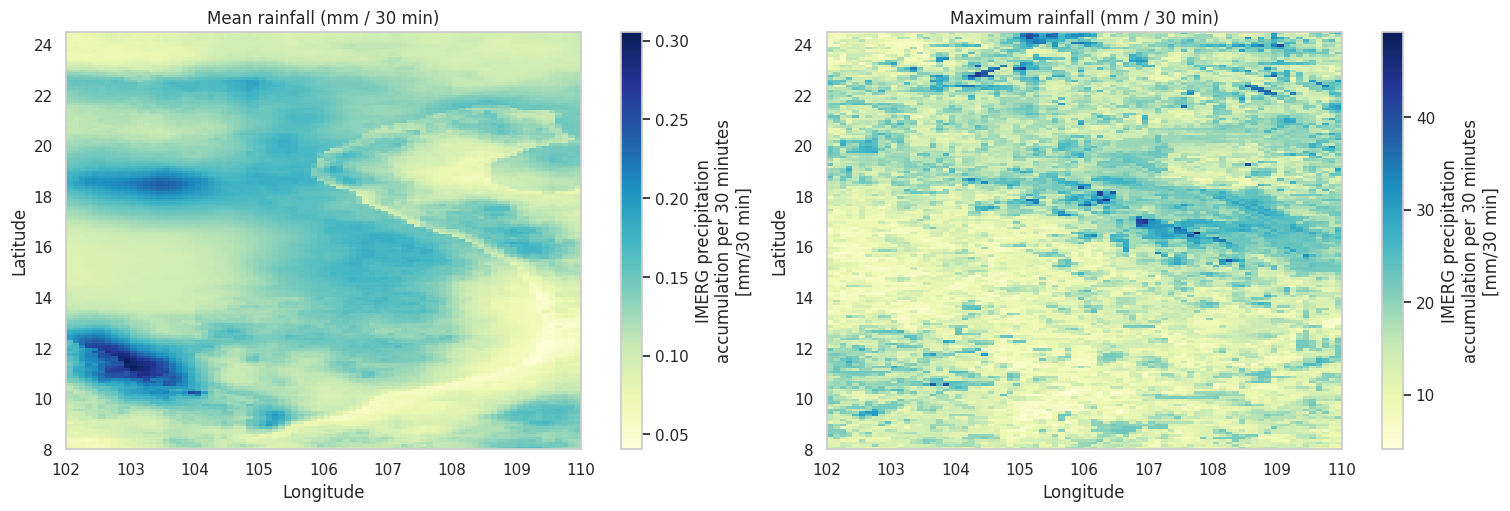

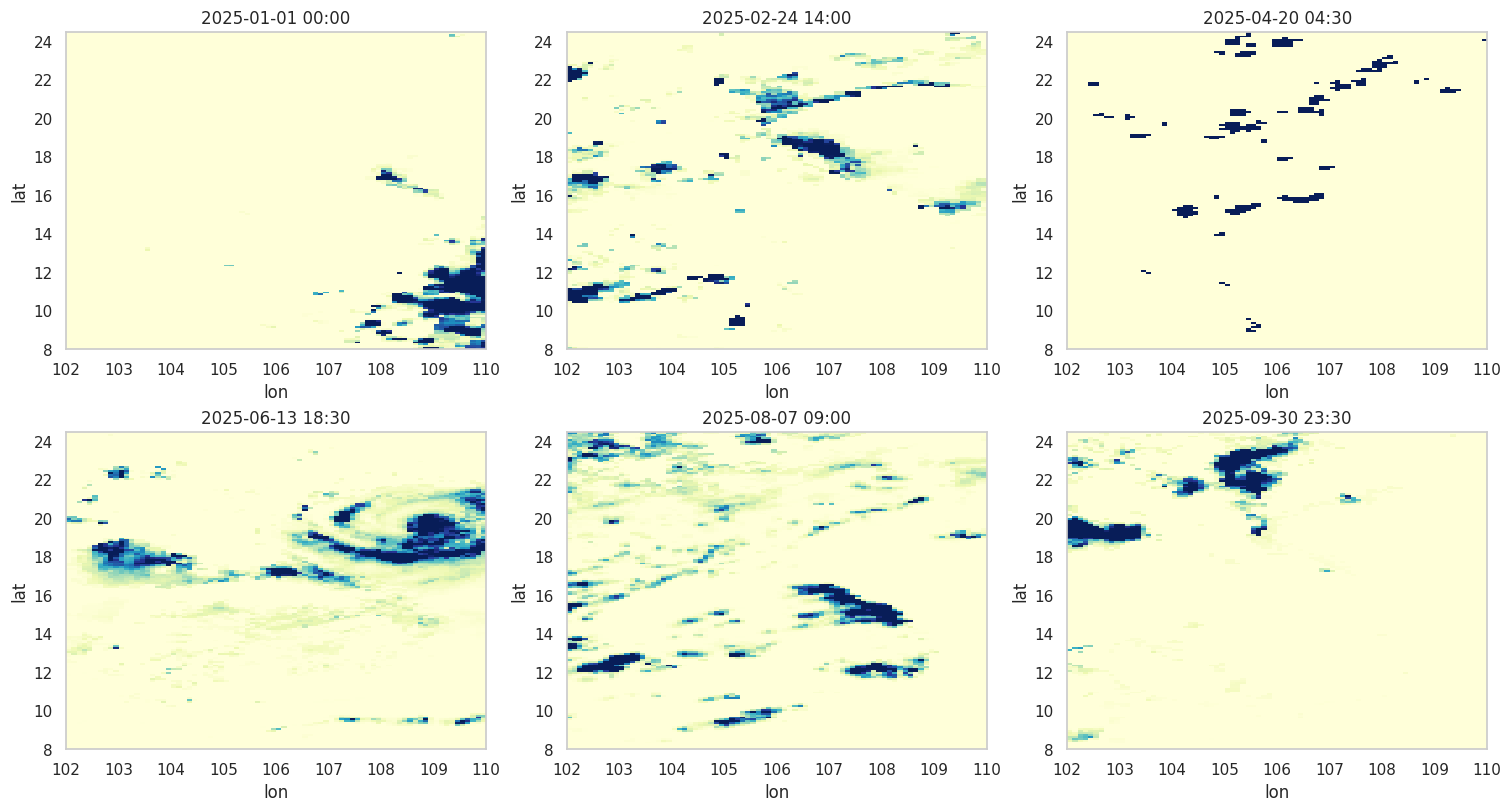

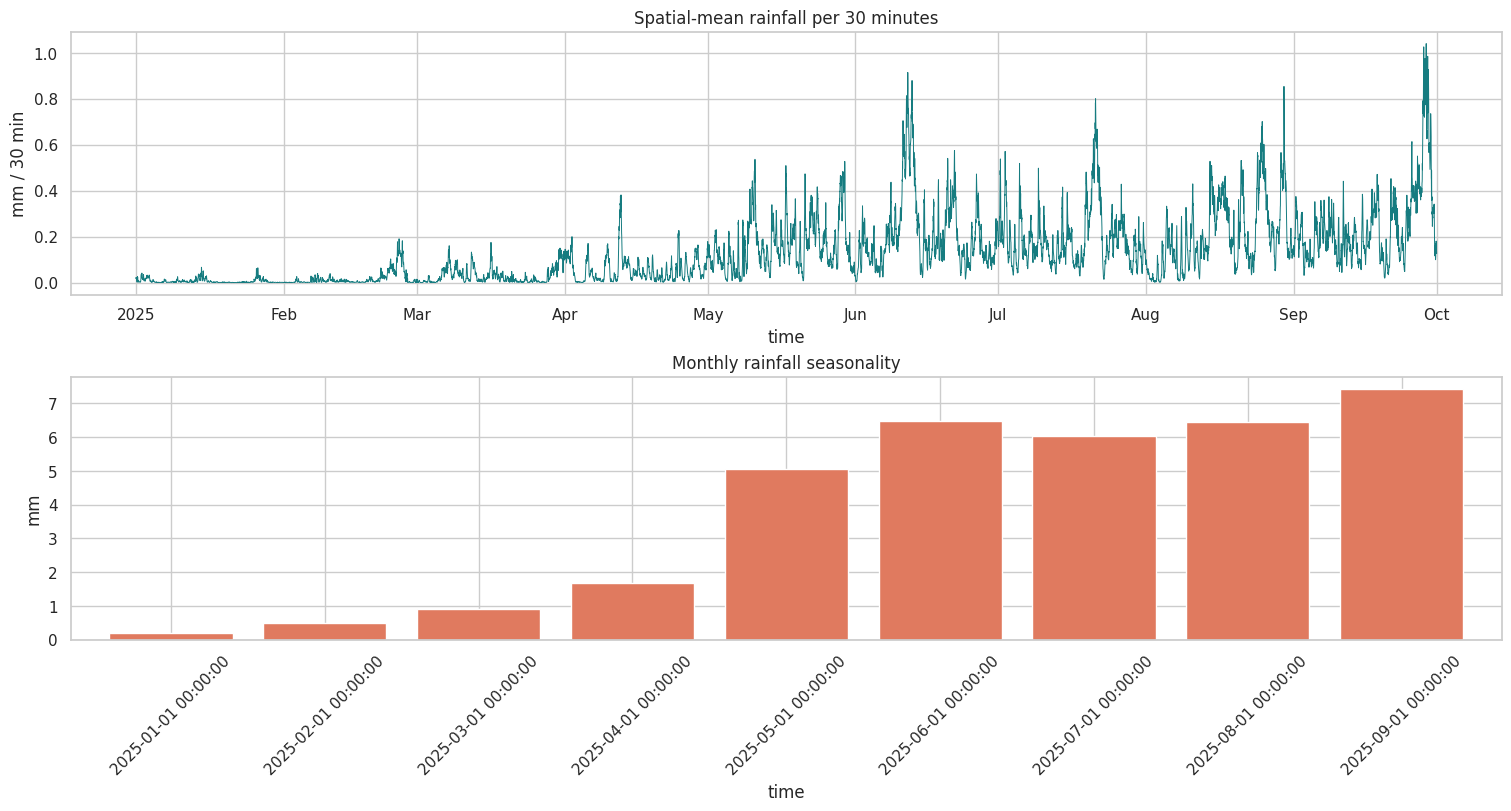

Wettest 10 half-hour timesteps:
time
2025-09-28 19:00:00    1.040359
2025-09-28 06:30:00    1.026103
2025-09-28 05:30:00    1.000519
2025-09-28 18:30:00    0.991233
2025-09-29 02:30:00    0.985175
2025-09-28 06:00:00    0.979206
2025-09-28 13:30:00    0.975847
2025-09-28 13:00:00    0.975063
2025-09-28 14:00:00    0.951816
2025-09-28 07:00:00    0.950648
Name: rainfall, dtype: float32


In [ ]:
mean_map = rain.mean("time", skipna=True)
max_map = rain.max("time", skipna=True)
fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
for axis, field, title in zip(axes, [mean_map, max_map], ["Mean rainfall", "Maximum rainfall"]):
    field.plot(ax=axis, cmap="YlGnBu", add_colorbar=True)
    axis.set_title(f"{title} (mm / 30 min)")
    axis.set_xlabel("Longitude")
    axis.set_ylabel("Latitude")
plt.savefig(FIG_DIR / "rainfall_mean_max_maps_2025_2026.png", dpi=160)
plt.show()

sample_indices = np.linspace(0, rain.sizes["time"] - 1, 6, dtype=int)
fig, axes = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)
for axis, index in zip(axes.flat, sample_indices):
    rain.isel(time=index).plot(ax=axis, cmap="YlGnBu", vmin=0, robust=True, add_colorbar=False)
    axis.set_title(pd.Timestamp(rain.time.values[index]).strftime("%Y-%m-%d %H:%M"))
plt.savefig(FIG_DIR / "rainfall_sample_frames_2025_2026.png", dpi=160)
plt.show()

spatial_mean = rain.mean(dim=("lat", "lon"), skipna=True)
daily_mean = spatial_mean.resample(time="1D").mean(skipna=True)
monthly_total = daily_mean.resample(time="1MS").sum(skipna=True)
fig, axes = plt.subplots(2, 1, figsize=(15, 8), constrained_layout=True)
spatial_mean.plot(ax=axes[0], color="#167c80", linewidth=0.7)
axes[0].set_title("Spatial-mean rainfall per 30 minutes")
axes[0].set_ylabel("mm / 30 min")
monthly_total.to_series().plot.bar(ax=axes[1], color="#e07a5f", width=0.8)
axes[1].set_title("Monthly rainfall seasonality")
axes[1].set_ylabel("mm")
axes[1].tick_params(axis="x", rotation=45)
plt.savefig(FIG_DIR / "rainfall_time_series_2025_2026.png", dpi=160)
plt.show()
print("Wettest 10 half-hour timesteps:")
print(spatial_mean.sortby(spatial_mean, ascending=False).head(10).to_pandas())

## 4. Kiểm tra cửa sổ nowcasting

Chọn một cửa sổ gồm 6 frame lịch sử và 4 frame mục tiêu tương lai. Dùng để kiểm tra continuity trước khi xây dựng Dataset và split train/validation/test.

Window: 2025-05-17 09:30:00 -> 2025-05-17 14:00:00
Input history: [Timestamp('2025-05-17 09:30:00'), Timestamp('2025-05-17 10:00:00'), Timestamp('2025-05-17 10:30:00'), Timestamp('2025-05-17 11:00:00'), Timestamp('2025-05-17 11:30:00'), Timestamp('2025-05-17 12:00:00')]
Forecast targets: [Timestamp('2025-05-17 12:30:00'), Timestamp('2025-05-17 13:00:00'), Timestamp('2025-05-17 13:30:00'), Timestamp('2025-05-17 14:00:00')]
Window intervals: <TimedeltaArray>
['0 days 00:30:00']
Length: 1, dtype: timedelta64[ns]


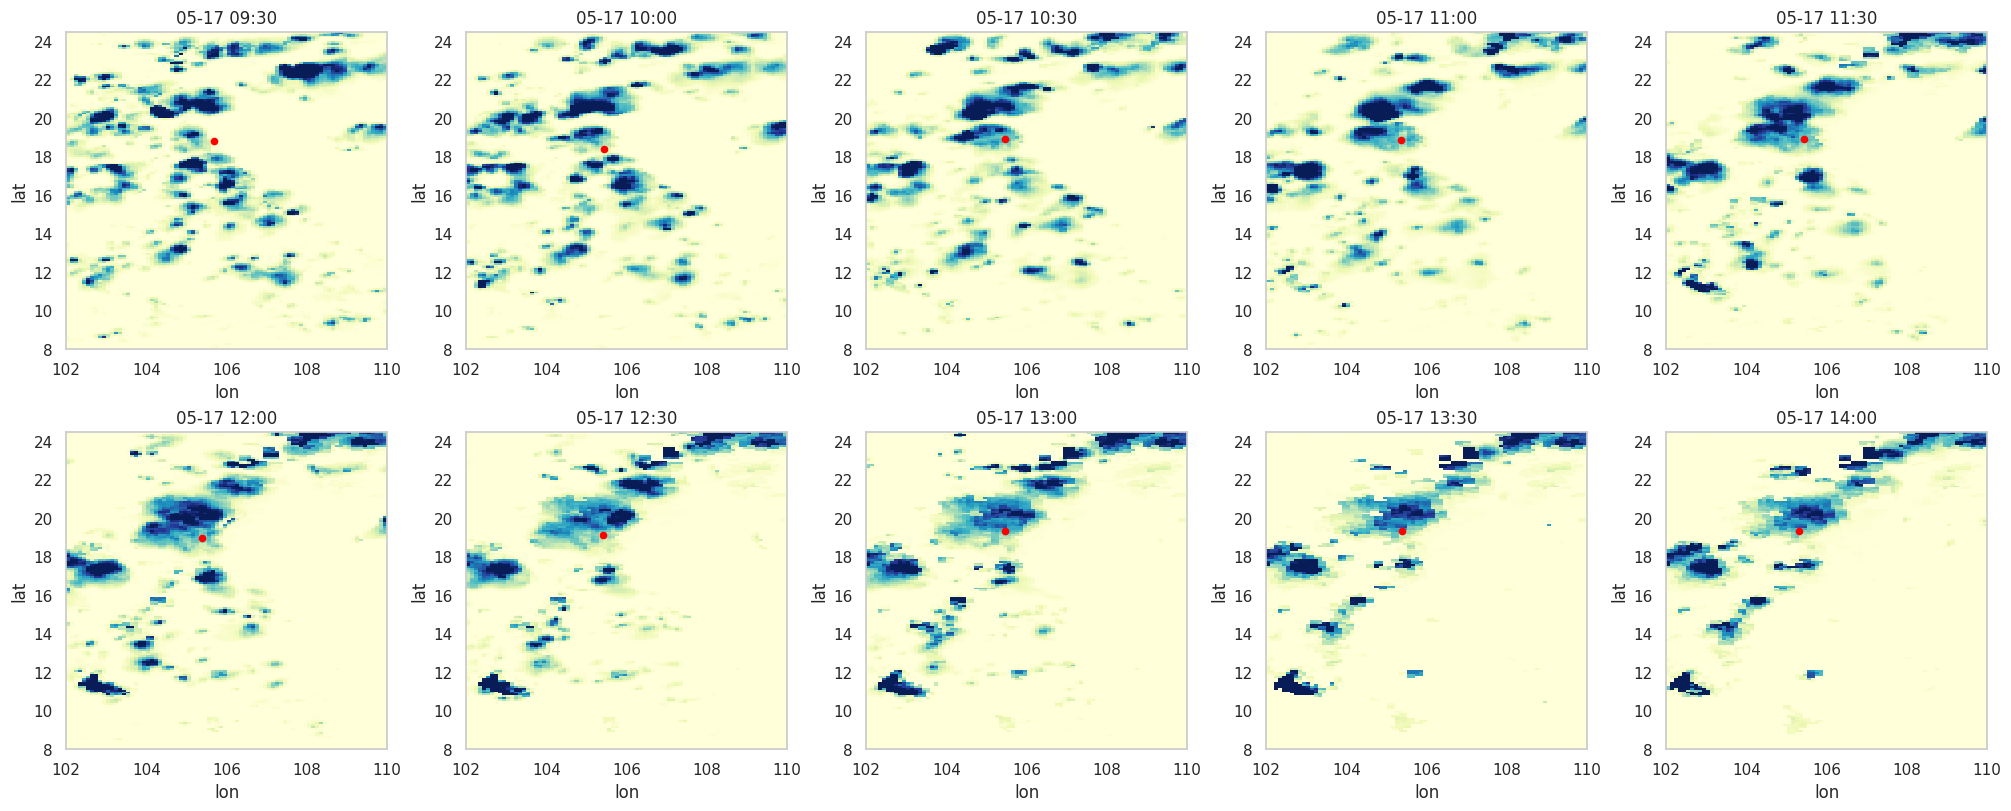

                     centroid_lat  centroid_lon  rainy_pixel_count
time                                                              
2025-05-17 09:30:00     18.821280    105.686478               4936
2025-05-17 10:00:00     18.419058    105.443062               4963
2025-05-17 10:30:00     18.921324    105.453766               4740
2025-05-17 11:00:00     18.890366    105.357361               4575
2025-05-17 11:30:00     18.904188    105.430237               3931
2025-05-17 12:00:00     18.973482    105.378601               3724
2025-05-17 12:30:00     19.157310    105.404991               3523
2025-05-17 13:00:00     19.357075    105.464012               3300
2025-05-17 13:30:00     19.328644    105.387421               2769
2025-05-17 14:00:00     19.338736    105.321579               2725


,from,to,spatial_correlation
0,2025-05-17 09:30:00,2025-05-17 10:00:00,0.593816
1,2025-05-17 10:00:00,2025-05-17 10:30:00,0.549089
2,2025-05-17 10:30:00,2025-05-17 11:00:00,0.700614
3,2025-05-17 11:00:00,2025-05-17 11:30:00,0.719411
4,2025-05-17 11:30:00,2025-05-17 12:00:00,0.807797
5,2025-05-17 12:00:00,2025-05-17 12:30:00,0.816880
6,2025-05-17 12:30:00,2025-05-17 13:00:00,0.859324
7,2025-05-17 13:00:00,2025-05-17 13:30:00,0.850401
8,2025-05-17 13:30:00,2025-05-17 14:00:00,0.896936


In [ ]:
HISTORY_STEPS = 6
FORECAST_STEPS = 4
WINDOW_SIZE = HISTORY_STEPS + FORECAST_STEPS
RAIN_THRESHOLD = 0.1

target_index = len(actual_time) // 2
start_index = target_index - HISTORY_STEPS + 1
end_index = start_index + WINDOW_SIZE
if start_index < 0 or end_index > len(actual_time):
    raise ValueError("Không đủ frame cho cửa sổ nowcasting 6+4.")

window_times = actual_time[start_index:end_index]
print(f"Window: {window_times[0]} -> {window_times[-1]}")
print("Input history:", window_times[:HISTORY_STEPS].tolist())
print("Forecast targets:", window_times[HISTORY_STEPS:].tolist())
print("Window intervals:", window_times.to_series().diff().dropna().unique())

fig, axes = plt.subplots(2, 5, figsize=(20, 8), constrained_layout=True)
centroids = []
for axis, index in zip(axes.flat, range(start_index, end_index)):
    frame = rain.isel(time=index)
    mask = frame >= RAIN_THRESHOLD
    count = int(mask.sum(skipna=True))
    weights = frame.where(mask).fillna(0)
    total = float(weights.sum())
    centroid_lat = float((weights * frame.lat).sum() / total) if total > 0 else np.nan
    centroid_lon = float((weights * frame.lon).sum() / total) if total > 0 else np.nan
    centroids.append((actual_time[index], centroid_lat, centroid_lon, count))
    frame.plot(ax=axis, cmap="YlGnBu", vmin=0, robust=True, add_colorbar=False)
    axis.set_title(actual_time[index].strftime("%m-%d %H:%M"))
    if np.isfinite(centroid_lat):
        axis.scatter([centroid_lon], [centroid_lat], color="red", s=20)
plt.savefig(FIG_DIR / "nowcasting_6_history_4_targets_2025_2026.png", dpi=160)
plt.show()

centroid_table = pd.DataFrame(centroids, columns=["time", "centroid_lat", "centroid_lon", "rainy_pixel_count"]).set_index("time")
print(centroid_table)

correlations = []
for left, right in zip(range(start_index, end_index - 1), range(start_index + 1, end_index)):
    first = rain.isel(time=left).values.ravel()
    second = rain.isel(time=right).values.ravel()
    valid = np.isfinite(first) & np.isfinite(second)
    correlation = np.corrcoef(first[valid], second[valid])[0, 1] if valid.sum() > 2 else np.nan
    correlations.append({"from": actual_time[left], "to": actual_time[right], "spatial_correlation": correlation})
frame_correlations = pd.DataFrame(correlations)
frame_correlations